In [5]:
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm, trange
import sys
import matplotlib.pyplot as plt
import pickle
import random

# variaveis
L = 100 # lado do lattice
n_lagartos = L**2 # lagartos que cabem no lattice
estrategias = ['O', 'Y', 'B'] # estratégias possíveis
index_map = {'O': 0, 'Y': 1, 'B': 2}
n_geracoes = 200
n_pop = 1 # número de populações independentes
prob_mutacao = None # probabilidade de mutação a cada geração
tipo = f"teste_i8_a24"
sigma = 0

output_dir = "C:\\Unicamp\\mestrado\\simulacoes\\RPS-python\\RPS-POO\\outputs\\vizinhanca_aprendizado-interacao\\" + tipo + f"/sigma_{str(sigma)}/"
os.makedirs(output_dir, exist_ok=True)

In [2]:
class Lagarto:
  def __init__(self, i, j, estrategia, fitness, coord_vizinhos_interacao, estrategia_vizinhos_interacao, coord_vizinhos_aprendizado, estrategia_vizinhos_aprendizado, t, n_vizinhos_interacao, n_vizinhos_aprendizado):
    self.i = i # linha
    self.j = j # coluna
    self.estrategia = estrategia
    self.fitness = 0 # inicia com 0 de fitness
    self.coord_vizinhos_interacao = [] # lista vazia para adicionar as coordenadas dos vizinhos
    self.estrategia_vizinhos_interacao = [] # lista vazia para adicionar as estratégias dos vizinhos
    self.coord_vizinhos_aprendizado = []
    self.estrategia_vizinhos_aprendizado = []
    self.t = t  # determina a geracao do lagarto
    self.n_vizinhos_interacao = n_vizinhos_interacao # número de vizinhos que o lagarto efetivamente joga
    self.n_vizinhos_aprendizado = n_vizinhos_aprendizado # número de vizinhos que o lagarto olha para aprender

  def calcular_coord_vizinhos(self, L): # obtém as coordenadas dos vizinhos
    # INTERAÇÃO
    vizinhos_possiveis_interacao = []
    n_v_i = self.n_vizinhos_interacao
    
    for dx in range(-3, 4):
        for dy in range(-3, 4):
            if dx == 0 and dy == 0:
                continue
            ni = (self.i + dx) % L
            nj = (self.j + dy) % L
            dist = max(abs(dx), abs(dy))
            vizinhos_possiveis_interacao.append(((ni, nj), dist))

    # Agrupa vizinhos por distância
    vizinhos_por_dist = {}
    for coord, dist in vizinhos_possiveis_interacao:
        vizinhos_por_dist.setdefault(dist, []).append(coord)

    selecionados = []
    for dist in sorted(vizinhos_por_dist.keys()):
        grupo = vizinhos_por_dist[dist]
        random.shuffle(grupo)
        faltam = n_v_i - len(selecionados)
        if faltam <= 0:
            break
        if len(grupo) <= faltam:
            selecionados.extend(grupo)
        else:
            selecionados.extend(random.sample(grupo, faltam))
    self.coord_vizinhos_interacao = selecionados[:n_v_i]

    # APRENDIZADO
    vizinhos_possiveis_aprendizado = []
    n_v_a = self.n_vizinhos_aprendizado

    for dx in range(-3, 4):
        for dy in range(-3, 4):
            if dx == 0 and dy == 0:
                continue
            ni = (self.i + dx) % L
            nj = (self.j + dy) % L
            dist = max(abs(dx), abs(dy))
            vizinhos_possiveis_aprendizado.append(((ni, nj), dist))

    vizinhos_por_dist_a = {}
    for coord, dist in vizinhos_possiveis_aprendizado:
        vizinhos_por_dist_a.setdefault(dist, []).append(coord)

    selecionados_a = []
    for dist in sorted(vizinhos_por_dist_a.keys()):
        grupo = vizinhos_por_dist_a[dist]
        random.shuffle(grupo)
        faltam = n_v_a - len(selecionados_a)
        if faltam <= 0:
            break
        if len(grupo) <= faltam:
            selecionados_a.extend(grupo)
        else:
            selecionados_a.extend(random.sample(grupo, faltam))
    self.coord_vizinhos_aprendizado = selecionados_a[:n_v_a]

  def obter_estrategia_vizinhos(self, matriz_posicao):
      self.estrategia_vizinhos_interacao = [matriz_posicao[ni, nj] for ni, nj in self.coord_vizinhos_interacao] # dadas as coordenadas, obtém a estratégia do lagarto que ocupa aquela posição
      self.estrategia_vizinhos_aprendizado = [matriz_posicao[ni, nj] for ni, nj in self.coord_vizinhos_aprendizado] # dadas as coordenadas, obtém a estratégia do lagarto que ocupa aquela posição

  def mutacao(self, prob_mutacao): # função de mutação
    if np.random.rand() < prob_mutacao: # sorteia um valor entre 0 e 1, se for menor que a probabilidade de mutação, o lagarto muda de estratégia
        estrategias_possiveis = [e for e in estrategias if e != self.estrategia] # obtém as estratégias possíveis, exceto a atual
        self.estrategia = np.random.choice(estrategias_possiveis) # escolhe uma nova estratégia aleatoriamente para mutar


### PRECISO DECIDIR QUANTOS VIZINHOS!!!
  def adicionar_vizinhos_inicial(self):
      if self.estrategia == 'Y':
          #n_vizinhos_interacao = np.random.randint(1, 9)
          n_vizinhos_interacao = 8
          self.n_vizinhos_interacao = n_vizinhos_interacao
          #n_vizinhos_aprendizado = np.random.randint(1, 9)
          n_vizinhos_aprendizado = 24
          self.n_vizinhos_aprendizado = n_vizinhos_aprendizado
      elif self.estrategia == 'O':
          #n_vizinhos_interacao = np.random.randint(1, 9)
          n_vizinhos_interacao = 8
          self.n_vizinhos_interacao = n_vizinhos_interacao
          #n_vizinhos_aprendizado = np.random.randint(1, 9)
          n_vizinhos_aprendizado = 24
          self.n_vizinhos_aprendizado = n_vizinhos_aprendizado
      elif self.estrategia == 'B':
          #n_vizinhos_interacao = np.random.randint(1, 9)
          n_vizinhos_interacao = 8
          self.n_vizinhos_interacao = n_vizinhos_interacao
          #n_vizinhos_aprendizado = np.random.randint(1, 9)
          n_vizinhos_aprendizado = 24
          self.n_vizinhos_aprendizado = n_vizinhos_aprendizado
###

def calcular_media_vizinhos(lagartos, estrategias, tipo):
    if tipo == 'interacao':
        medias_interacao = []
        for e in estrategias:
            #viz = [lag.n_vizinhos_realizado for lag in lagartos if lag.estrategia == e]
            viz = [lag.n_vizinhos_interacao for lag in lagartos if lag.estrategia == e]
            medias_interacao.append(np.mean(viz) if len(viz) > 0 else 0)
        return medias_interacao # retorna a média de vizinhos para cada estratégia

    elif tipo == 'aprendizado':
        medias_aprendizado = []
        for e in estrategias:
            viz = [lag.n_vizinhos_aprendizado for lag in lagartos if lag.estrategia == e]
            medias_aprendizado.append(np.mean(viz) if len(viz) > 0 else 0)
        return medias_aprendizado # retorna a média de vizinhos para cada estratégia

In [3]:
def criar_lagartos(n_lagartos, L, estrategias): # define as posições e estratégias dos lagartos no t = 0
  lista_lagartos = []

  # posições iniciais aleatórias
  all_positions = [(i, j) for i in range(L) for j in range(L)] # forma todas as posições possíveis em um lattice
  unique_positions_indices = np.random.choice(len(all_positions), n_lagartos, replace=False) # determina o índice de onde vai ficar cada posição
  unique_positions = [all_positions[i] for i in unique_positions_indices] # basicamente, ele embaralhou as posições

  for g in range(n_lagartos):
    i, j = unique_positions[g] # posição na matriz
    estrategia = np.random.choice(estrategias) # sorteia a estrategia
    lista_lagartos.append(Lagarto(i, j, estrategia, 0, [], [], [], [], 0, 0, 0)) # cria o lagarto
  return lista_lagartos

def calcular_fitness(lagarto, index_map, matriz_posicao, sigma): # função para calcular o fitness do lagarto
    fitness_total = 0 # inicia no 0

    b = 2
    c = 1.5

    matriz_payoff = np.array([[1, b-c, b],
                              [b, 1, b-c],
                              [b-c, b, 1]])
    
    vizinhos_interacao = set(lagarto.coord_vizinhos_interacao)
    for ni, nj in vizinhos_interacao:
        vizinho_estrat = matriz_posicao[ni, nj] # pega a estratégia do vizinho dadas as suas coordenadas
        if vizinho_estrat is not None:
            fitness_total += matriz_payoff[index_map[lagarto.estrategia], index_map[vizinho_estrat]] # calcula o payoff do lagarto contra o vizinho de acordo com a matriz de payoff e soma ao fitness total
    lagarto.fitness = fitness_total + np.random.normal(0, sigma) # adiciona ruído gaussiano ao fitness
    return fitness_total

calcular_freq = lambda mat: np.array([np.sum(mat == s) / (L ** 2) for s in ['O', 'Y', 'B']]) # calcula a frequência de cada estratégia no lattice na ordem O, Y, B

In [4]:
def atualizar_lagartos(lagartos): # função que atualiza as estratégias dos lagartos com base no fitness dos vizinhos
    novas_estrategias = {} # Dicionário para armazenar as novas estratégias
    novas_vizinhancas_aprendizado = {} # Dicionário para armazenar as novas vizinhanças de aprendizado
    novas_vizinhancas_interacao = {} # Dicionário para armazenar as novas vizinhanças de interação

    mapa = {(l.i, l.j): l for l in lagartos} # dicionário para acessar lagartos pela posição

    for lagarto in lagartos:
        melhor_estrategia = lagarto.estrategia # inicia com a própria estratégia
        maior_fitness = lagarto.fitness # verifica o fitness do próprio lagarto
        melhor_vizinhanca_aprendizado = lagarto.n_vizinhos_aprendizado
        melhor_vizinhanca_interacao = lagarto.n_vizinhos_interacao
            
        # verifica o fitness dos vizinhos
        for (ni, nj) in lagarto.coord_vizinhos_aprendizado:
            vizinho = mapa[(ni, nj)] # usa o dicionário para achar o vizinho
            if vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior fitness atual
                maior_fitness = vizinho.fitness # atualiza o maior fitness
                melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                melhor_vizinhanca_aprendizado = vizinho.n_vizinhos_aprendizado # atualiza a melhor vizinhança
                melhor_vizinhanca_interacao = vizinho.n_vizinhos_interacao
            if vizinho.fitness == maior_fitness:
                a = np.random.rand()
                if a < 0.5:
                    maior_fitness = vizinho.fitness # atualiza o maior fitness
                    melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                    melhor_vizinhanca_aprendizado = vizinho.n_vizinhos_aprendizado # atualiza a melhor vizinhança
                    melhor_vizinhanca_interacao = vizinho.n_vizinhos_interacao
                else:
                    pass
                # se houver empate de fitness ou for menor, mantém a estratégia atual (não muda)

        novas_estrategias[(lagarto.i, lagarto.j)] = melhor_estrategia # armazena a nova estratégia no dicionário
        novas_vizinhancas_aprendizado[(lagarto.i, lagarto.j)] = melhor_vizinhanca_aprendizado # armazena a nova vizinhança no dicionário
        novas_vizinhancas_interacao[(lagarto.i, lagarto.j)] = melhor_vizinhanca_interacao # armazena a nova vizinhança no dicionário

     # atualiza as estratégias de todos os lagartos simultaneamente
    for lagarto in lagartos:
        lagarto.estrategia = novas_estrategias[(lagarto.i, lagarto.j)]  # atualiza estratégia
        # Garantir tamanhos fixos para O e B; somente Y herda vizinhança adaptativa
        #if lagarto.estrategia == 'O':
            #lagarto.n_vizinhos = 24
        #elif lagarto.estrategia == 'B':
            #lagarto.n_vizinhos = 8
        #else:  # 'Y'
        lagarto.n_vizinhos_aprendizado = novas_vizinhancas_aprendizado[(lagarto.i, lagarto.j)]
        lagarto.n_vizinhos_interacao = novas_vizinhancas_interacao[(lagarto.i, lagarto.j)]
        #lagarto.n_vizinhos = novas_vizinhancas[(lagarto.i, lagarto.j)]
    
    return lagartos

In [6]:
# iniciando a simulação
def simulacao(n_geracoes, L, n_lagartos, estrategias, index_map, n_pop, sigma, prob_mutacao = None, seed = None):
    matriz_frequencias = np.full((n_geracoes + 1, n_pop, len(estrategias)), np.nan, dtype=float) # cria uma matriz para armazenar as frequências em cada instante dos loops
    matriz_n_vizinhos_aprendizado_media = np.full((n_geracoes + 1, n_pop, len(estrategias)), np.nan, dtype=float) # cria uma matriz para armazenar vizinhos
    n_vizinhos_aprendizado_individual = []  # lista para armazenar todos os números de vizinhos
    matriz_n_vizinhos_interacao_media = np.full((n_geracoes + 1, n_pop, len(estrategias)), np.nan, dtype=float) # cria uma matriz para armazenar vizinhos
    n_vizinhos_interacao_individual = []  # lista para armazenar todos os números de vizinhos
    historico_estrategias = [] # lista para armazenar o histórico de estratégias de cada população

    for pop in range(n_pop): # loop para cada população independente
        if seed is not None:
          np.random.seed(seed + pop) # coloca uma semente diferente pra cada pop, garantindo independência e reproducibilidade

        frequencias = [] # vai armazenar as frequências ao longo das gerações para essa população
        matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
        historico_estrategias_pop = []
        n_vizinhos_aprendizado_pop = []
        n_vizinhos_interacao_pop = []

        lista_lagartos = criar_lagartos(n_lagartos, L, estrategias) # cria os lagartos
        for lagarto in lista_lagartos:
            lagarto.adicionar_vizinhos_inicial() # adiciona o número de vizinhos iniciais de acordo com a estratégia
            matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos

        frequencias.append(calcular_freq(matriz_posicao)) # calcula a frequência inicial
        n_vizinhos_aprendizado_pop.append([lagarto.n_vizinhos_aprendizado for lagarto in lista_lagartos])  # geração inicial
        n_vizinhos_interacao_pop.append([lagarto.n_vizinhos_interacao for lagarto in lista_lagartos])  # geração inicial
        historico_estrategias_pop.append([lagarto.estrategia for lagarto in lista_lagartos])  # histórico de estratégias
        matriz_n_vizinhos_aprendizado_media[0, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias, 'aprendizado')
        matriz_n_vizinhos_interacao_media[0, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias, 'interacao')

        for t in range(1, n_geracoes + 1): # loop para cada geração dentro da população
          # determinando os vizinhos
          for lagarto in lista_lagartos:
            lagarto.calcular_coord_vizinhos(L) # calcula as coordenadas dos vizinhos
            lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos

          # calculando o fitness
          for lagarto in lista_lagartos:
            calcular_fitness(lagarto, index_map, matriz_posicao, sigma) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

          lista_lagartos = atualizar_lagartos(lista_lagartos) # atualiza as estratégias dos lagartos de acordo com o maior fitness dos vizinhos

          if prob_mutacao is not None:
            for lagarto in lista_lagartos:
              lagarto.mutacao(prob_mutacao) # aplica a mutação

          # atualiza a matriz de posição com as novas estratégias e com as mutações
          matriz_posicao = np.full((L, L), None)
          for lagarto in lista_lagartos:
            matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)
          #print(matriz_posicao)

          n_vizinhos_aprendizado_geracao = [lagarto.n_vizinhos_aprendizado for lagarto in lista_lagartos]
          n_vizinhos_aprendizado_pop.append(n_vizinhos_aprendizado_geracao)
          n_vizinhos_interacao_geracao = [lagarto.n_vizinhos_interacao for lagarto in lista_lagartos]
          n_vizinhos_interacao_pop.append(n_vizinhos_interacao_geracao)
          matriz_n_vizinhos_aprendizado_media[t, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias, 'aprendizado') # calcula a média de vizinhos para cada estratégia e armazena na matriz n_vizinhos
          matriz_n_vizinhos_interacao_media[t, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias, 'interacao') # calcula a média de vizinhos para cada estratégia e armazena na matriz n_vizinhos
          #print(matriz_n_vizinhos[t, pop, :]) # debug
          historico_estrategias_pop.append([lagarto.estrategia for lagarto in lista_lagartos])  # histórico de estratégias
          frequencias.append(calcular_freq(matriz_posicao)) # calcula a frequência dessa geração e armazena em frequencias

          for lagarto in lista_lagartos:
              lagarto.t += 1 # incrementa a geração do lagarto
          
        frequencias = np.array(frequencias)
        n_vizinhos_aprendizado_individual.append(n_vizinhos_aprendizado_pop)
        n_vizinhos_interacao_individual.append(n_vizinhos_interacao_pop)
        historico_estrategias.append(historico_estrategias_pop)
        for t in range(n_geracoes + 1):
          matriz_frequencias[t, pop, :] = frequencias[t]

          # >>>>> SALVAR OS DADOS DESTA POPULAÇÃO <<<<<
        with open(os.path.join(output_dir, f"pop_{pop}_n_vizinhos_aprendizado_individual.pkl"), "wb") as f:
          pickle.dump(n_vizinhos_aprendizado_pop, f)
        with open(os.path.join(output_dir, f"pop_{pop}_n_vizinhos_interacao_individual.pkl"), "wb") as f:
          pickle.dump(n_vizinhos_interacao_pop, f)
        with open(os.path.join(output_dir, f"pop_{pop}_historico_estrategias.pkl"), "wb") as f:
          pickle.dump(historico_estrategias_pop, f)
        np.save(os.path.join(output_dir, f"pop_{pop}_matriz_frequencias.npy"), frequencias)
        np.save(os.path.join(output_dir, f"pop_{pop}_matriz_n_vizinhos_aprendizado_media.npy"), matriz_n_vizinhos_aprendizado_media[:, pop, :])
        np.save(os.path.join(output_dir, f"pop_{pop}_matriz_n_vizinhos_interacao_media.npy"), matriz_n_vizinhos_interacao_media[:, pop, :])
            # >>>>> FIM DO SALVAMENTO <<<<<

    return matriz_frequencias, matriz_n_vizinhos_aprendizado_media, matriz_n_vizinhos_interacao_media, n_vizinhos_aprendizado_individual, n_vizinhos_interacao_individual, historico_estrategias

freq, n_vizinhos_aprendizado, n_vizinhos_interacao, n_vizinhos_aprendizado_individual, n_vizinhos_interacao_individual, historico_estrategias = simulacao(n_geracoes, L, n_lagartos, estrategias, index_map, n_pop, sigma=sigma, prob_mutacao = prob_mutacao, seed = 2)

In [7]:
freq

array([[[0.3352, 0.3399, 0.3249]],

       [[0.3114, 0.3747, 0.3139]],

       [[0.2655, 0.3614, 0.3731]],

       [[0.3151, 0.3368, 0.3481]],

       [[0.3655, 0.2939, 0.3406]],

       [[0.3626, 0.301 , 0.3364]],

       [[0.3379, 0.342 , 0.3201]],

       [[0.3222, 0.3608, 0.317 ]],

       [[0.327 , 0.3426, 0.3304]],

       [[0.3297, 0.3379, 0.3324]],

       [[0.3261, 0.3332, 0.3407]],

       [[0.3327, 0.3187, 0.3486]],

       [[0.34  , 0.3068, 0.3532]],

       [[0.3503, 0.3024, 0.3473]],

       [[0.3553, 0.302 , 0.3427]],

       [[0.3481, 0.3127, 0.3392]],

       [[0.3571, 0.3177, 0.3252]],

       [[0.3546, 0.3293, 0.3161]],

       [[0.3311, 0.3544, 0.3145]],

       [[0.3276, 0.3538, 0.3186]],

       [[0.3199, 0.349 , 0.3311]],

       [[0.301 , 0.3486, 0.3504]],

       [[0.2912, 0.3324, 0.3764]],

       [[0.3323, 0.3012, 0.3665]],

       [[0.3669, 0.2882, 0.3449]],

       [[0.3921, 0.3   , 0.3079]],

       [[0.3913, 0.3188, 0.2899]],

       [[0.3408, 0.3574, 0.3

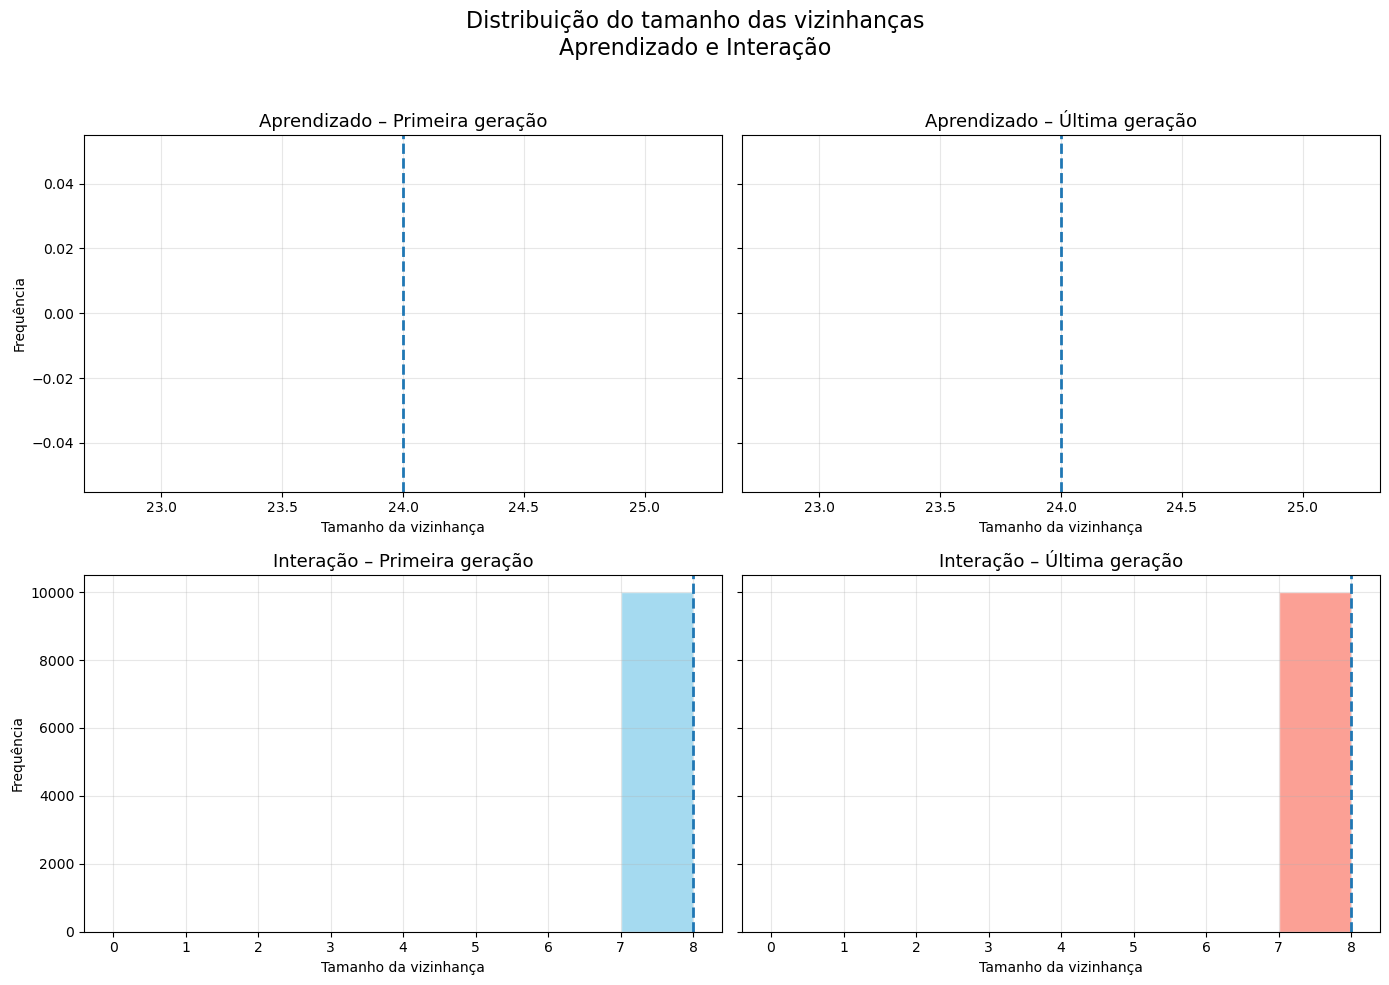

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Preparação dos dados
# =========================
todos_primeira_aprendizado = []
todos_ultima_aprendizado = []
todos_primeira_interacao = []
todos_ultima_interacao = []

for pop in range(len(n_vizinhos_aprendizado_individual)):
    todos_primeira_aprendizado.extend(n_vizinhos_aprendizado_individual[pop][0])
    todos_ultima_aprendizado.extend(n_vizinhos_aprendizado_individual[pop][-1])

for pop in range(len(n_vizinhos_interacao_individual)):
    todos_primeira_interacao.extend(n_vizinhos_interacao_individual[pop][0])
    todos_ultima_interacao.extend(n_vizinhos_interacao_individual[pop][-1])

# =========================
# Configurações visuais
# =========================
bins_aprend = np.arange(
    min(todos_primeira_aprendizado + todos_ultima_aprendizado),
    max(todos_primeira_aprendizado + todos_ultima_aprendizado) + 1
)

bins_inter = np.arange(0, 9)

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharey='row')

def hist_estilizado(ax, dados, bins, cor, titulo, xlabel):
    ax.hist(
        dados,
        bins=bins,
        color=cor,
        alpha=0.75,
        edgecolor='white'
    )
    ax.axvline(
        np.mean(dados),
        linestyle='--',
        linewidth=2,
    )
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3)

# =========================
# Histogramas
# =========================
hist_estilizado(
    axs[0, 0],
    todos_primeira_aprendizado,
    bins_aprend,
    'skyblue',
    'Aprendizado – Primeira geração',
    'Tamanho da vizinhança'
)

hist_estilizado(
    axs[0, 1],
    todos_ultima_aprendizado,
    bins_aprend,
    'salmon',
    'Aprendizado – Última geração',
    'Tamanho da vizinhança'
)

hist_estilizado(
    axs[1, 0],
    todos_primeira_interacao,
    bins_inter,
    'skyblue',
    'Interação – Primeira geração',
    'Tamanho da vizinhança'
)

hist_estilizado(
    axs[1, 1],
    todos_ultima_interacao,
    bins_inter,
    'salmon',
    'Interação – Última geração',
    'Tamanho da vizinhança'
)

axs[0, 0].set_ylabel('Frequência')
axs[1, 0].set_ylabel('Frequência')

fig.suptitle(
    'Distribuição do tamanho das vizinhanças\nAprendizado e Interação',
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(output_dir, f"distribuicao_vizinhas.png"), dpi=100)
plt.show()


In [9]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

def simulacao_gif(n_geracoes, L, n_lagartos, estrategias, index_map, sigma, prob_mutacao = None, seed = None):

    matrizes_posicao_hist = [] # lista para armazenar as matrizes de posição de cada geração
    matrizes_fitness_hist = []
    matrizes_vizinhanca_interacao_hist = []
    matrizes_vizinhanca_aprendizado_hist = []

    if seed is not None:
        np.random.seed(seed) # coloca uma semente diferente pra cada pop

    # criando a matriz inicial
    matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
    matriz_fitness = np.full((L, L), 0.0) # cria uma matriz vazia com 0
    matriz_vizinhanca_interacao = np.full((L, L), 0.0)
    matriz_vizinhanca_aprendizado = np.full((L, L), 0.0)

    lista_lagartos = criar_lagartos(n_lagartos, L, estrategias) # cria os lagartos
    for lagarto in lista_lagartos:
        lagarto.adicionar_vizinhos_inicial() # adiciona o número de vizinhos iniciais de acordo com a estratégia
        matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos
        matriz_vizinhanca_interacao[lagarto.i, lagarto.j] = lagarto.n_vizinhos_interacao
        matriz_vizinhanca_aprendizado[lagarto.i, lagarto.j] = lagarto.n_vizinhos_aprendizado

    matrizes_posicao_hist.append(matriz_posicao.copy()) # junta as matrizes em uma lista
    matrizes_fitness_hist.append(matriz_fitness.copy())
    matrizes_vizinhanca_interacao_hist.append(matriz_vizinhanca_interacao.copy())
    matrizes_vizinhanca_aprendizado_hist.append(matriz_vizinhanca_aprendizado.copy())

    for t in range(1, n_geracoes + 1):
    # criando os vizinhos
      print(f"Geração {t}")
      for lagarto in lista_lagartos:
          lagarto.calcular_coord_vizinhos(L) # calcula as coordenadas dos vizinhos
          lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos

        # calculando o fitness
      for lagarto in lista_lagartos:
          calcular_fitness(lagarto, index_map, matriz_posicao, sigma) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

      matriz_fitness = np.full((L, L), 0.0)
      for lagarto in lista_lagartos:
        matriz_fitness[lagarto.i, lagarto.j] = float(lagarto.fitness) # coloca os fitness nas posições
        matriz_vizinhanca_aprendizado[lagarto.i, lagarto.j] = lagarto.n_vizinhos_aprendizado
        matriz_vizinhanca_interacao[lagarto.i, lagarto.j] = lagarto.n_vizinhos_interacao
      #print(matriz_fitness)

      lista_lagartos = atualizar_lagartos(lista_lagartos)

      # atualiza a matriz de posição com as novas estratégias e com as mutações
      matriz_posicao = np.full((L, L), None)
      for lagarto in lista_lagartos:
        matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)

      for lagarto in lista_lagartos:
            lagarto.t += 1
      
      #print(matriz_posicao)

      matrizes_posicao_hist.append(matriz_posicao.copy()) # Append updated matrix position
      matrizes_fitness_hist.append(matriz_fitness.copy())
      matrizes_vizinhanca_interacao_hist.append(matriz_vizinhanca_interacao.copy())
      matrizes_vizinhanca_aprendizado_hist.append(matriz_vizinhanca_aprendizado.copy())

    return matrizes_posicao_hist, matrizes_fitness_hist, matrizes_vizinhanca_interacao_hist, matrizes_vizinhanca_aprendizado_hist # Return both frequencies and matrix history

matrizes_posicao_hist, matrizes_fitness_hist, matrizes_vizinhanca_interacao_hist, matrizes_vizinhanca_aprendizado_hist = simulacao_gif(n_geracoes, L, n_lagartos, estrategias, index_map, sigma = sigma, prob_mutacao=prob_mutacao, seed=1)

Geração 1
Geração 2
Geração 3
Geração 4
Geração 5
Geração 6
Geração 7
Geração 8
Geração 9
Geração 10
Geração 11
Geração 12
Geração 13
Geração 14
Geração 15
Geração 16
Geração 17
Geração 18
Geração 19
Geração 20
Geração 21
Geração 22
Geração 23
Geração 24
Geração 25
Geração 26
Geração 27
Geração 28
Geração 29
Geração 30
Geração 31
Geração 32
Geração 33
Geração 34
Geração 35
Geração 36
Geração 37
Geração 38
Geração 39
Geração 40
Geração 41
Geração 42
Geração 43
Geração 44
Geração 45
Geração 46
Geração 47
Geração 48
Geração 49
Geração 50
Geração 51
Geração 52
Geração 53
Geração 54
Geração 55
Geração 56
Geração 57
Geração 58
Geração 59
Geração 60
Geração 61
Geração 62
Geração 63
Geração 64
Geração 65
Geração 66
Geração 67
Geração 68
Geração 69
Geração 70
Geração 71
Geração 72
Geração 73
Geração 74
Geração 75
Geração 76
Geração 77
Geração 78
Geração 79
Geração 80
Geração 81
Geração 82
Geração 83
Geração 84
Geração 85
Geração 86
Geração 87
Geração 88
Geração 89
Geração 90
Geração 91
Geração 

In [10]:
print(np.mean(matrizes_vizinhanca_aprendizado_hist[0]))
print(np.mean(matrizes_vizinhanca_aprendizado_hist[-1]))
print(np.mean(matrizes_vizinhanca_interacao_hist[0]))
print(np.mean(matrizes_vizinhanca_interacao_hist[-1]))

24.0
24.0
8.0
8.0


In [11]:
# gerando o GIF das posições

import matplotlib.colors as mcolors

cores_grid = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

def matriz_para_rgb(matriz):
    # Converte hex para RGB normalizado (0-1)
    return np.array([[mcolors.to_rgb(cores_grid.get(cell, "#FFFFFF")) for cell in row] for row in matriz])

# Crie a figura
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(matriz_para_rgb(matrizes_posicao_hist[frame]))
    ax.set_title(f"Geração {frame}")
    ax.axis('off')

ani = animation.FuncAnimation(
    fig, update, frames=len(matrizes_posicao_hist), interval=100, repeat=False
)


# Salvar como GIF
ani.save(os.path.join(output_dir, f"simulacao_grid.gif"), writer='pillow', fps=10)
ani.save(os.path.join(output_dir, f"simulacao_grid.mp4"), writer='ffmpeg', fps=1)
plt.close()

In [12]:
# gerando o GIF dos fitness

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrizes_fitness_hist[0], cmap='viridis', vmin=-10, vmax=np.max(matrizes_fitness_hist))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Fitness')

def update_fitness(frame):
    im.set_data(matrizes_fitness_hist[frame])
    ax.set_title(f"Fitness - Geração {frame}")
    ax.axis('off')
    return [im]

ani = animation.FuncAnimation(
    fig, update_fitness, frames=len(matrizes_fitness_hist), interval=100, blit=False, repeat=False
)

ani.save(os.path.join(output_dir, f"simulacao_fitness.gif"), writer='pillow', fps=1)
ani.save(os.path.join(output_dir, f"simulacao_fitness.mp4"), writer='ffmpeg', fps=1)
plt.close()

In [13]:
# gerando o GIF das vizinhancas de interação

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrizes_vizinhanca_interacao_hist[0], cmap='viridis', vmin=0, vmax=np.max(matrizes_vizinhanca_interacao_hist))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Número de Vizinhos de Interação')

def update_vizinhanca_interacao(frame):
    im.set_data(matrizes_vizinhanca_interacao_hist[frame])
    ax.set_title(f"Número de Vizinhos de Interação - Geração {frame}")
    ax.axis('off')
    return [im]

ani = animation.FuncAnimation(
    fig, update_vizinhanca_interacao, frames=len(matrizes_vizinhanca_interacao_hist), interval=100, blit=False, repeat=False
)

ani.save(os.path.join(output_dir, f"simulacao_vizinhanca_interacao.gif"), writer='pillow', fps=1)
ani.save(os.path.join(output_dir, f"simulacao_vizinhanca_interacao.mp4"), writer='ffmpeg', fps=1)
plt.close()

In [14]:
# gerando o GIF das vizinhancas de aprendizado

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrizes_vizinhanca_aprendizado_hist[0], cmap='viridis', vmin=0, vmax=np.max(matrizes_vizinhanca_aprendizado_hist))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Número de Vizinhos de Aprendizado')

def update_vizinhanca_aprendizado(frame):
    im.set_data(matrizes_vizinhanca_aprendizado_hist[frame])
    ax.set_title(f"Número de Vizinhos de Aprendizado - Geração {frame}")
    ax.axis('off')
    return [im]

ani = animation.FuncAnimation(
    fig, update_vizinhanca_aprendizado, frames=len(matrizes_vizinhanca_aprendizado_hist), interval=100, blit=False, repeat=False
)

ani.save(os.path.join(output_dir, f"simulacao_vizinhanca_aprendizado.gif"), writer='pillow', fps=1)
ani.save(os.path.join(output_dir, f"simulacao_vizinhanca_aprendizado.mp4"), writer='ffmpeg', fps=1)
plt.close()